# For Gianna

You're welcome :)

## Conclusion

This report compared **Old** and **Young** participants on fifteen trial-level metrics. **Univariate** Mann–Whitney tests with **FDR** control showed **eight** metrics with reliable group differences, concentrated in **spatial misplacement** and **item accuracy** (especially larger set sizes and squiggles), with **weaker** evidence for **between-item transitions** (objects-6) and **dwell time** (squiggles-6). **Entropy** and several transition/dwell measures did **not** survive multiple-comparison adjustment, so they should not be overstated as group markers in this sample.

**Multivariate** views complemented those tests: **PCA** gives a low-dimensional picture of how people spread out in metric space; **k-means** and **supervised** models ask whether **combinations** of metrics separate groups better than any single score. **Stratified cross-validated** logistic regression and random forest both performed **meaningfully above chance**, with **logistic regression** slightly **stronger on overall accuracy** in this run and a clearer **interpretation** path. **SHAP** on the full-sample logistic model showed **which scaled metrics push individual predictions** toward **Young** vs **Old** on the log-odds scale, in line with the fitted **coefficients**.

**Limitations:** *n* = 100 is **small** for stable multivariate learning and for precise estimates of test error; **correlation** among metrics means several “significant” univariate findings are **not** independent effects. Out-of-fold **CV** is the appropriate read on **prediction**; the **SHAP** section describes **one** fully fit classifier for transparency, not a new estimate of generalization. Together, the analyses support **consistent group-level differences** in spatial and accuracy-related behavior, with **moderate** ability to predict cohort from metrics alone and a **coherent linear story** for how the model uses each measure.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import false_discovery_control

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import shap

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120



## Read Data

In [13]:
df = pd.read_csv("data/data.csv")
display(df["group"].value_counts().rename("n"))

metric_cols = [c for c in df.columns if c not in ("group", "subject")]
display(df[metric_cols].describe().T.round(3))

group
Young    51
Old      49
Name: n, dtype: int64

,count,mean,std,min,25%,50%,75%,max
avg_item_accuracy_objects1,100.0,76.767,13.433,45.833,66.319,79.167,86.111,98.611
avg_item_accuracy_objects6,100.0,76.300,13.928,44.444,65.278,75.000,88.131,98.611
avg_item_accuracy_squiggles6,100.0,66.318,11.122,38.889,58.333,65.278,76.389,87.500
avg_spatial_misplacement_objects1,100.0,186.035,54.372,100.819,144.725,178.693,213.165,358.610
avg_spatial_misplacement_objects6,100.0,169.362,46.230,66.775,130.917,166.617,204.730,279.878
avg_spatial_misplacement_squiggles6,100.0,263.872,68.422,149.531,204.416,261.049,314.540,406.071
dwell_time_per_item_avg_objects1,100.0,2604.602,199.688,1776.528,2484.578,2629.262,2756.424,3023.736
dwell_time_per_item_avg_objects6,100.0,2607.004,189.099,1993.028,2498.246,2626.011,2735.358,2989.375
dwell_time_per_item_avg_squiggles6,100.0,2671.669,238.428,1088.986,2600.826,2693.096,2802.799,3081.394
avg_between_item_transitions_objects1,100.0,23.105,5.104,12.000,19.792,23.167,26.511,41.500


## Boxplots

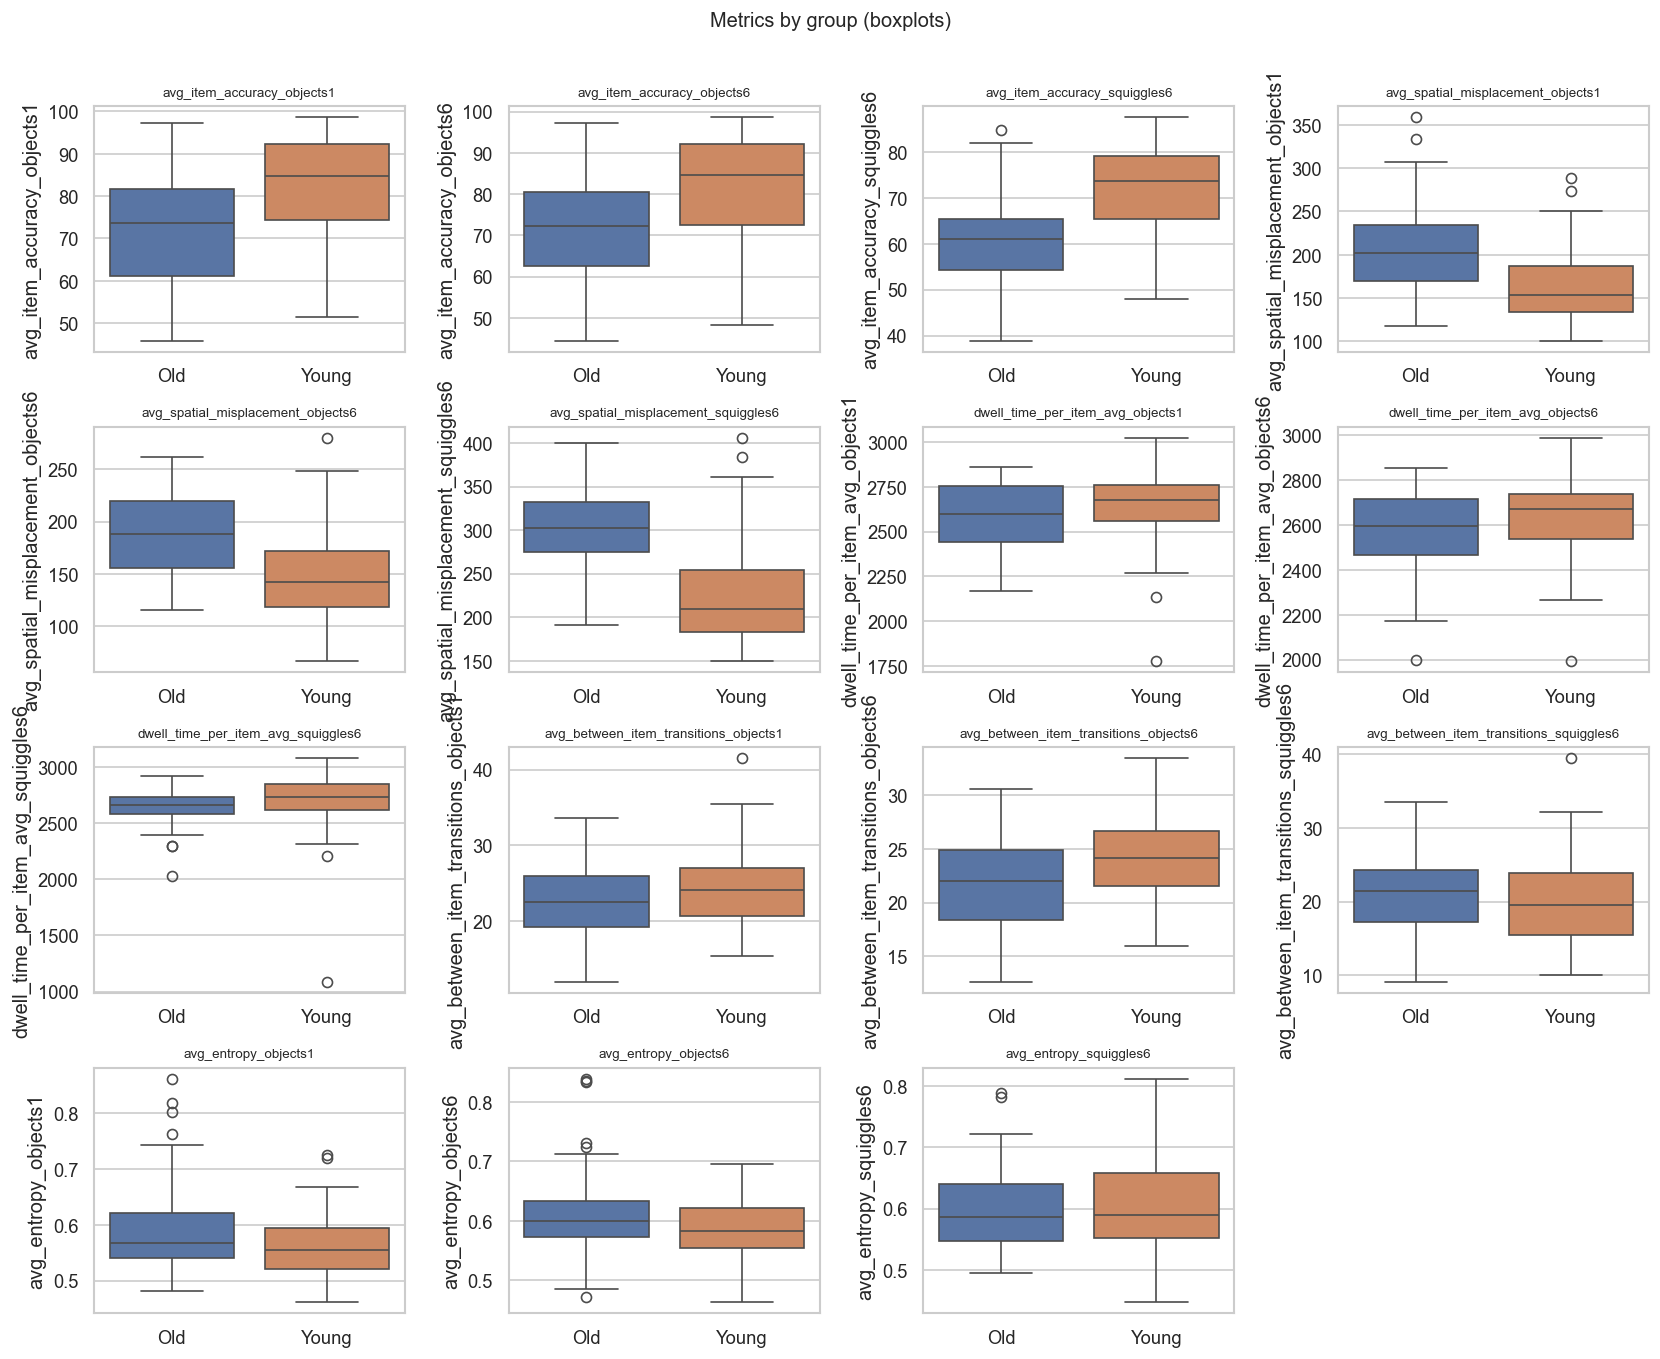

In [14]:
n = len(metric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, metric_cols):
    sns.boxplot(data=df, x="group", y=col, hue="group", ax=ax, order=["Old", "Young"], legend=False)
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("")
for j in range(len(metric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Metrics by group (boxplots)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## Violin & Strip

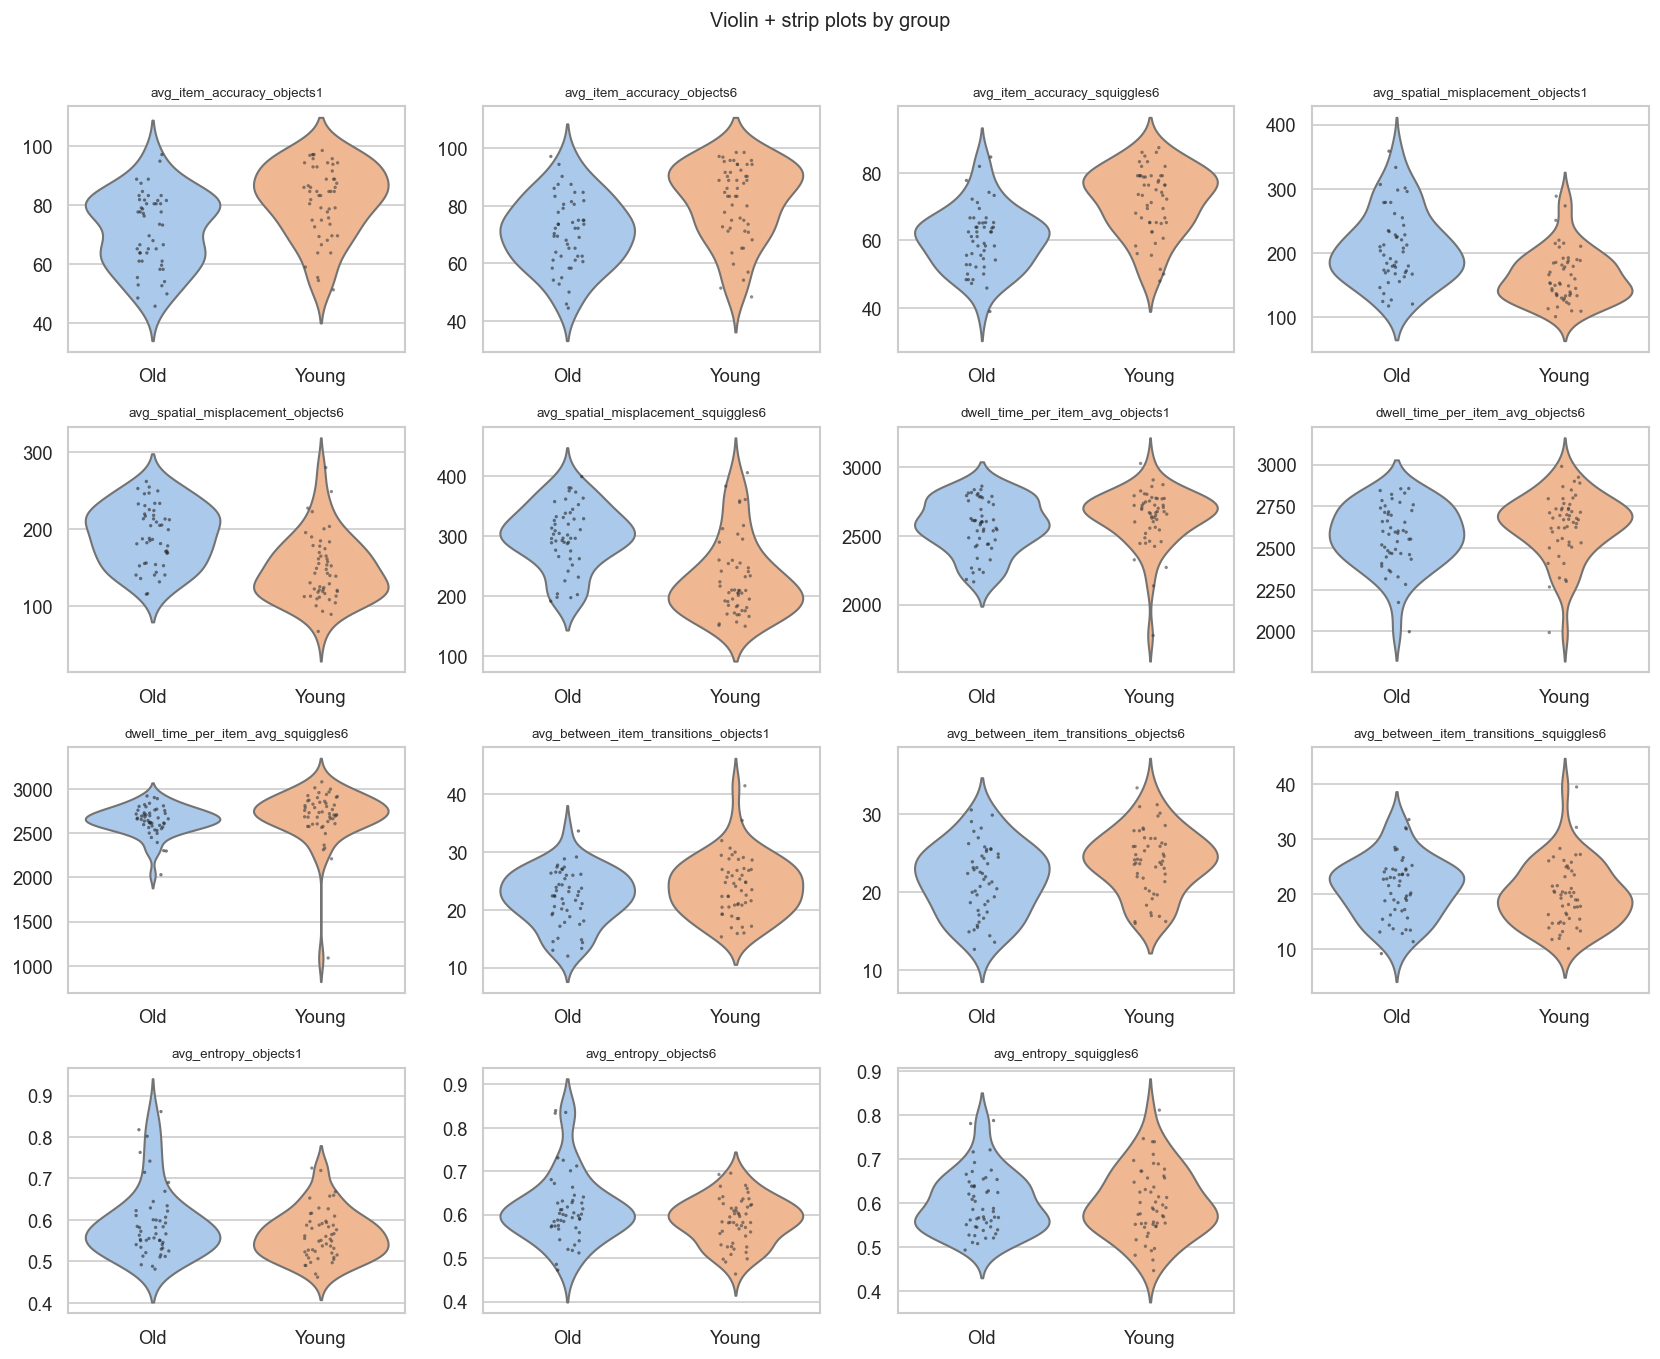

In [15]:
_n = len(metric_cols)
_ncols = 4
_nrows = int(np.ceil(_n / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(14, 2.8 * _nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, metric_cols):
    sns.violinplot(data=df, x="group", y=col, hue="group", ax=ax, order=["Old", "Young"], legend=False, inner=None, palette="pastel")
    sns.stripplot(data=df, x="group", y=col, hue="group", ax=ax, order=["Old", "Young"], color="0.25", size=2, alpha=0.6)
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
for j in range(len(metric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Violin + strip plots by group", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## Correlation Heatmap

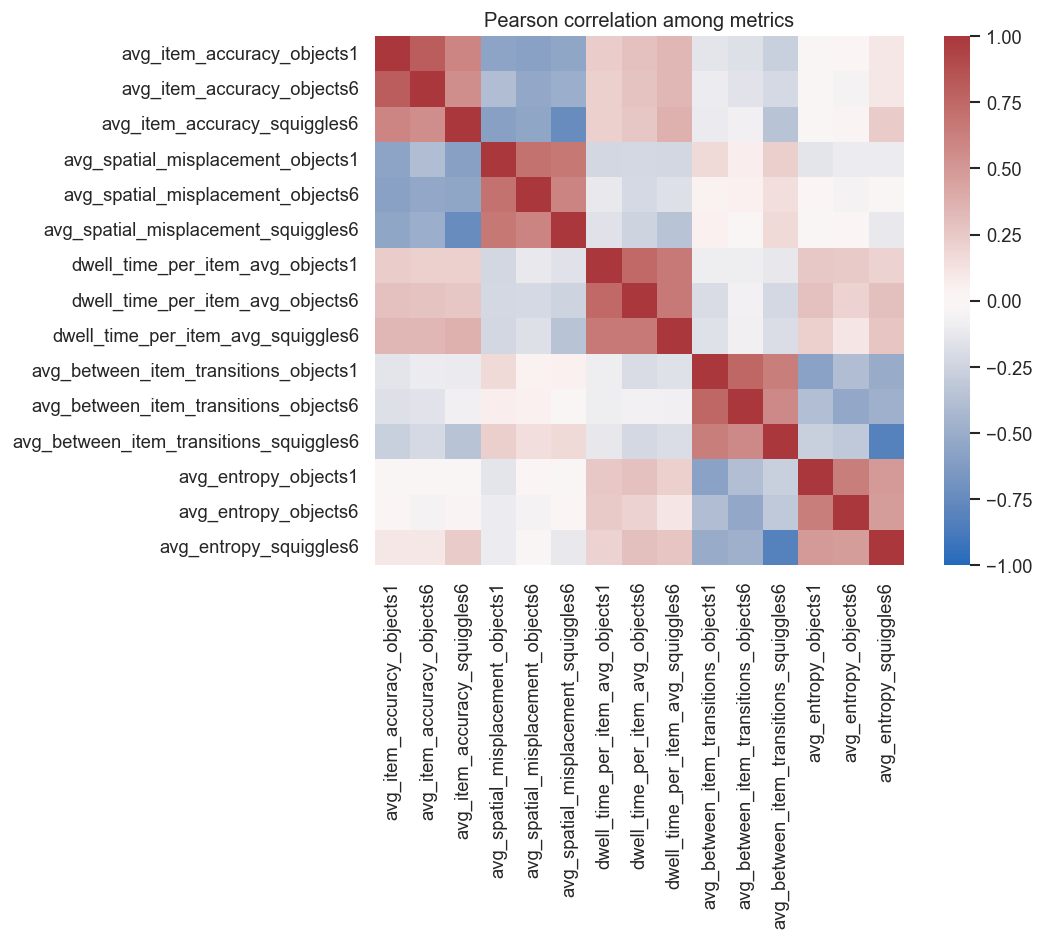

In [16]:
corr = df[metric_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, cmap="vlag", center=0, vmin=-1, vmax=1, square=True)
ax.set_title("Pearson correlation among metrics")
plt.tight_layout()
plt.show()

## Statistical tests

- **Mann–Whitney U** (nonparametric two-sample test)
- **Welch’s t-test** (parametric, unequal variances)
- **Benjamini–Hochberg FDR** is applied to the Mann–Whitney *p*-values (primary). Significance at FDR α = 0.05.

In [17]:
rows = []
for col in metric_cols:
    o = df.loc[df["group"] == "Old", col].to_numpy()
    yng = df.loc[df["group"] == "Young", col].to_numpy()
    mw = stats.mannwhitneyu(o, yng, alternative="two-sided")
    tt = stats.ttest_ind(o, yng, equal_var=False)
    rows.append(
        {
            "metric": col,
            "p_mannwhitney": mw.pvalue,
            "p_welch": tt.pvalue,
            "statistic_mw": mw.statistic,
        }
    )
tests = pd.DataFrame(rows).set_index("metric")
tests["p_mw_fdr_bh"] = false_discovery_control(tests["p_mannwhitney"].to_numpy())
tests["sig_fdr_0.05"] = tests["p_mw_fdr_bh"] < 0.05
tests = tests.sort_values("p_mannwhitney")
display(tests.round(6))

sig_n = int(tests["sig_fdr_0.05"].sum())
print(f"Metrics with Mann–Whitney FDR < 0.05: {sig_n} / {len(metric_cols)}")

,p_mannwhitney,p_welch,statistic_mw,p_mw_fdr_bh,sig_fdr_0.05
metric,,,,,
avg_spatial_misplacement_squiggles6,0.000000,0.000000,2013.0,0.000002,True
avg_item_accuracy_squiggles6,0.000000,0.000000,506.5,0.000002,True
avg_spatial_misplacement_objects6,0.000001,0.000001,1962.0,0.000005,True
avg_spatial_misplacement_objects1,0.000035,0.000021,1850.0,0.000132,True
avg_item_accuracy_objects6,0.000063,0.000061,669.0,0.000189,True
avg_item_accuracy_objects1,0.000123,0.000128,692.5,0.000309,True
avg_between_item_transitions_objects6,0.011163,0.008244,881.0,0.023546,True
dwell_time_per_item_avg_squiggles6,0.012558,0.248266,887.0,0.023546,True
dwell_time_per_item_avg_objects6,0.062645,0.087717,979.0,0.104408,False


Metrics with Mann–Whitney FDR < 0.05: 8 / 15


### Interpreting comparison table

For each metric we report a **Mann–Whitney *U*** *p*-value comparing Old vs Young without assuming normal distributions. 

Testing many metrics inflates the chance of false positives, so we add **Benjamini–Hochberg FDR** (`p_mw_fdr_bh`): adjusted *p*-values such that, among metrics called significant at 5%, a bounded fraction of those calls are expected to be false discoveries. **`sig_fdr_0.05`** marks metrics whose FDR-adjusted *p*-value is below 0.05.

- Eight of fifteen metrics differ reliably between groups after FDR control. 
- The strongest shifts involve spatial misplacement and item accuracy (largest set size and squiggles conditions first, then objects). 
    - Between-item transitions** show a group difference for the **objects-6** condition only
    - dwell time differs for squiggles-6 only
    - Entropy and the remaining transition/dwell metrics do **not** survive multiple-comparison adjustment, so should be considered as **not** showing robust group separation in this sample.

**Caveat.** These are univariate tests, i.e. each row ignores the others. Correlated metrics are partly redundant, so “8 significant” does not mean eight independent effects. The next sections use **multivariate** views (PCA, clustering, supervised models) to see how metrics combine.

## PCA and *k*-means

**PCA** projects participants into 2D for visualization (linear combinations that capture most variance). **K-means** (*k* = 2) asks whether natural clusters align with Old/Young; **adjusted Rand index (ARI)** compares cluster labels to true group (chance-corrected; 1 = perfect agreement).

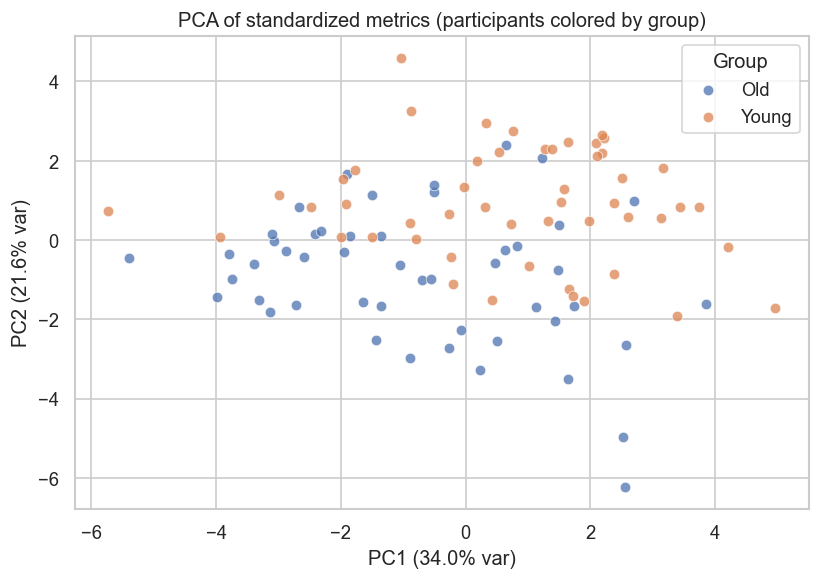

K-means (k=2) vs group — adjusted Rand index: 0.093


In [18]:
X = df[metric_cols].to_numpy()
le = LabelEncoder()
y_true = le.fit_transform(df["group"])

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xz)

fig, ax = plt.subplots(figsize=(7, 5))
for g, c in zip(["Old", "Young"], ["#4c72b0", "#dd8452"]):
    m = df["group"].values == g
    ax.scatter(Z[m, 0], Z[m, 1], label=g, alpha=0.75, s=40, c=c, edgecolors="white", linewidths=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA of standardized metrics (participants colored by group)")
ax.legend(title="Group")
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clus = kmeans.fit_predict(Xz)
ari = adjusted_rand_score(y_true, clus)
print(f"K-means (k=2) vs group — adjusted Rand index: {ari:.3f}")

## Supervised models: predicting group from metrics

**Stratified 5-fold cross-validation** (same splits for each model) gives out-of-fold predictions so metrics are not optimistic on small *n*. Models: **logistic regression** (linear, interpretable) and **random forest** (nonlinear). Report **precision / recall / F1** per class (Old, Young) and confusion matrices.

----------------------------------------------------------------------------------------------------
Logistic regression (5-fold CV, OOF predictions)
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

         Old      0.741     0.816     0.777        49
       Young      0.804     0.725     0.763        51

    accuracy                          0.770       100
   macro avg      0.773     0.771     0.770       100
weighted avg      0.773     0.770     0.770       100

----------------------------------------------------------------------------------------------------
Random forest (5-fold CV)
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

         Old      0.745     0.714     0.729        49
       Young      0.736     0.765     0.750        51

    accuracy                  

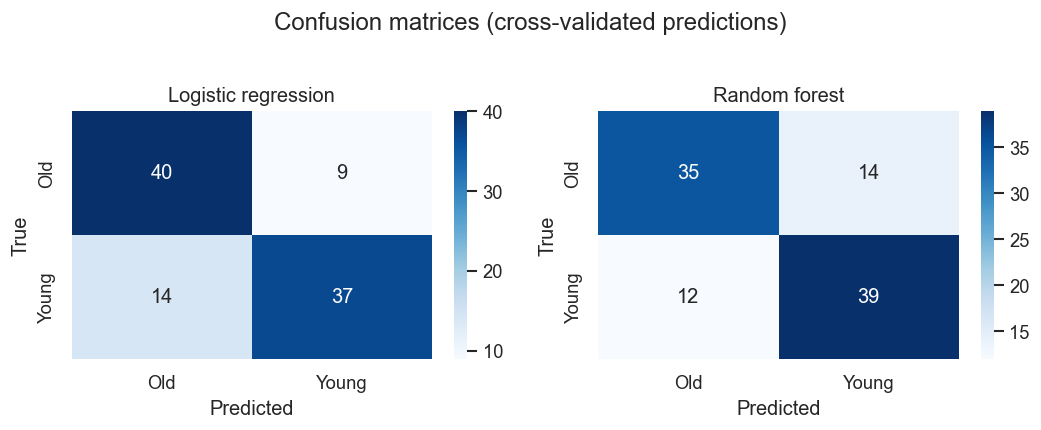

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, random_state=42)),
    ]
)
rf_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=400,
                random_state=42,
                class_weight="balanced_subsample",
                max_depth=4,
            ),
        ),
    ]
)

y_pred_log = cross_val_predict(log_pipe, X, y_true, cv=cv)
y_pred_rf = cross_val_predict(rf_pipe, X, y_true, cv=cv)

labels = list(le.classes_)
print("-" * 100)
print("Logistic regression (5-fold CV, OOF predictions)")
print("-" * 100)
print(classification_report(y_true, y_pred_log, target_names=labels, digits=3))

print("-" * 100)
print("Random forest (5-fold CV)")
print("-" * 100)
print(classification_report(y_true, y_pred_rf, target_names=labels, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, yp, title in zip(
    axes,
    [y_pred_log, y_pred_rf],
    ["Logistic regression", "Random forest"],
):
    cm = confusion_matrix(y_true, yp, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
plt.suptitle("Confusion matrices (cross-validated predictions)", y=1.02)
plt.tight_layout()
plt.show()

### Reading the supervised results (5-fold CV)

**Accuracy** (~**77%** logistic, ~**74%** random forest) is the fraction of participants correctly labeled when each fold’s model predicts people it did not train on. 

**Precision** for a class answers: *when the model predicts that class, how often is it right?* **Recall** answers: *of everyone who truly belongs to that class, how many did we catch?* 

**Logistic regression** is somewhat **better at finding Old participants** (recall ~0.82 vs ~0.71 for the forest) while the **random forest** is **better at finding Young** (recall ~0.77 vs ~0.73). Logistic **precision** is similar for Old (~0.74 both models) and a bit **higher for Young** when predicted (~0.80 vs ~0.74). So the lift in overall accuracy for logistic regression comes mainly from **fewer missed Old** cases, not from uniformly dominating every metric.

**Logistic regression** here is a bit **more accurate** overall than this **random forest** (shallow trees, class-balanced sampling). More importantly for the next section, logistic regression is a **linear** model on scaled features: each metric contributes additively on the log-odds scale, so **SHAP** can use the exact **`LinearExplainer`** and line up cleanly with **coefficients**. The forest can capture mild nonlinearity but is a **black box** for attribution unless we add a separate tree-based explainer—and here it does **not** improve CV accuracy enough to outweigh a clear linear model. We therefore use **logistic regression** for the SHAP visualizations.

## Logistic regression SHAP

,coef_(Young_log_odds),mean_abs_SHAP
avg_between_item_transitions_objects6,0.9474,0.7740
avg_between_item_transitions_squiggles6,-0.7611,0.6116
avg_spatial_misplacement_squiggles6,-0.6806,0.5923
dwell_time_per_item_avg_objects1,0.7305,0.5601
avg_item_accuracy_squiggles6,0.6640,0.5510
avg_spatial_misplacement_objects6,-0.6433,0.5398
dwell_time_per_item_avg_squiggles6,-0.7168,0.4454
avg_item_accuracy_objects6,0.4503,0.3804
avg_entropy_objects6,-0.4523,0.3221
avg_between_item_transitions_objects1,0.2962,0.2344


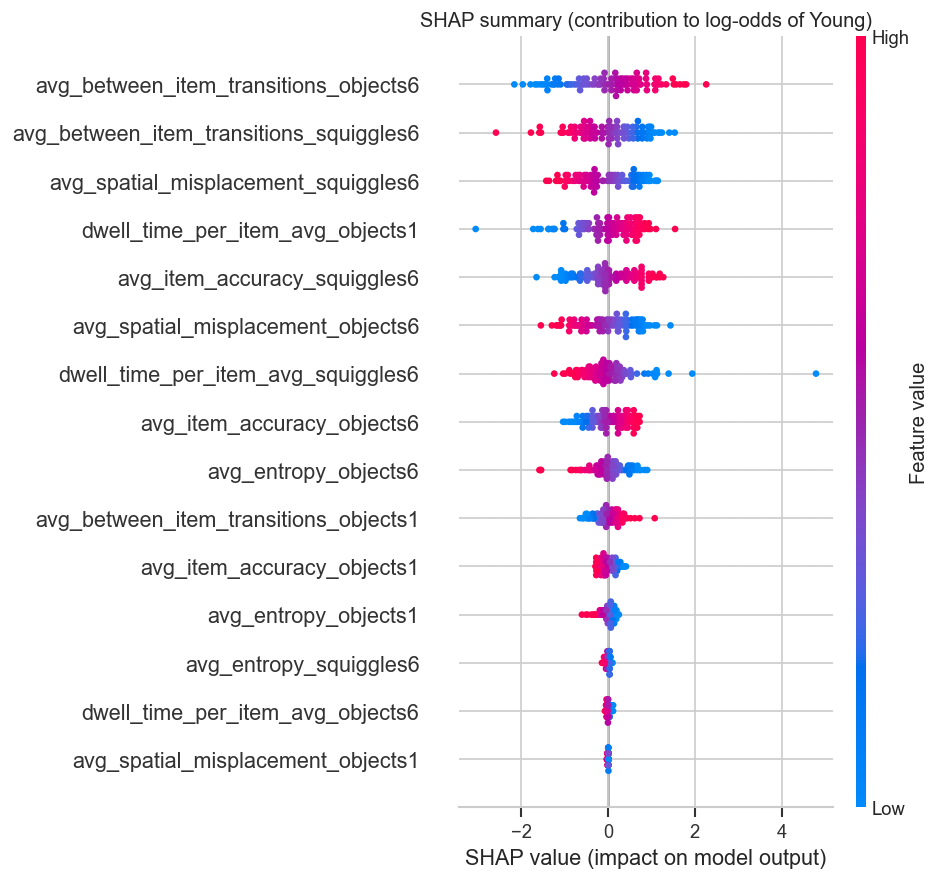

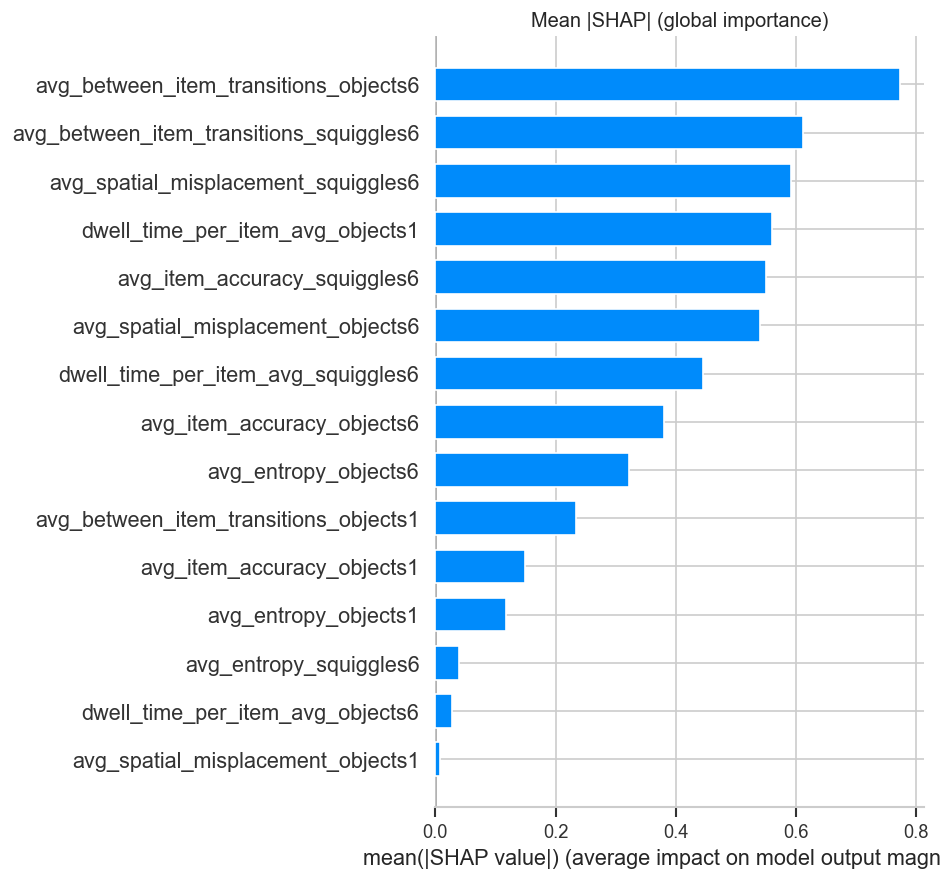

<Figure size 840x540 with 0 Axes>

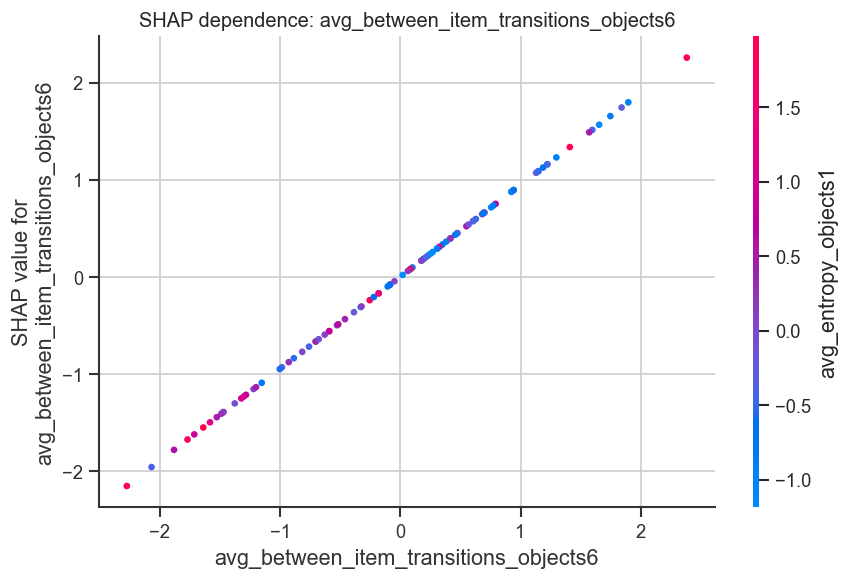

<Figure size 840x540 with 0 Axes>

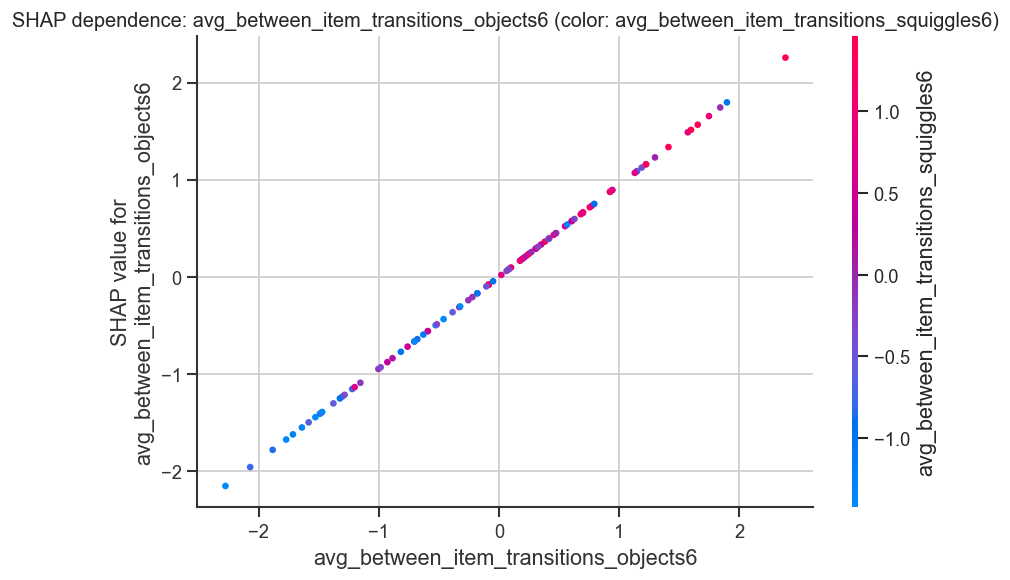

''

In [ ]:
scaler_shap = StandardScaler()
Xz_shap = scaler_shap.fit_transform(X)
log_full = LogisticRegression(max_iter=3000, random_state=42)
log_full.fit(Xz_shap, y_true)

explainer = shap.LinearExplainer(log_full, Xz_shap)
shap_vals = explainer.shap_values(Xz_shap)
base = float(np.asarray(explainer.expected_value).ravel()[0])

coef_tbl = pd.DataFrame(
    {
        "coef_(Young_log_odds)": log_full.coef_.ravel(),
        "mean_abs_SHAP": np.mean(np.abs(shap_vals), axis=0),
    },
    index=metric_cols,
).sort_values("mean_abs_SHAP", ascending=False)
display(coef_tbl.round(4))

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_vals, Xz_shap, feature_names=metric_cols, show=False)
plt.title("SHAP summary (contribution to log-odds of Young)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_vals, Xz_shap, feature_names=metric_cols, plot_type="bar", show=False
)
plt.title("Mean |SHAP| (global importance)")
plt.tight_layout()
plt.show()


top_j = int(np.argmax(np.mean(np.abs(shap_vals), axis=0)))
top_name = metric_cols[top_j]
plt.figure(figsize=(7, 4.5))
shap.dependence_plot(
    top_j,
    shap_vals,
    Xz_shap,
    feature_names=metric_cols,
    show=False,
)
plt.title(f"SHAP dependence: {top_name}")
plt.tight_layout()
plt.show()

second_j = int(
    np.argsort(np.mean(np.abs(shap_vals), axis=0))[-2]
)
plt.figure(figsize=(7, 4.5))
shap.dependence_plot(
    top_j,
    shap_vals,
    Xz_shap,
    feature_names=metric_cols,
    interaction_index=second_j,
    show=False,
)
plt.title(
    f"SHAP dependence: {top_name} (color: {metric_cols[second_j]})"
)
plt.tight_layout()
plt.show()